In [1]:
import os
import cv2
from numpy.random import f
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from PIL import Image
import imagehash
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from collections import Counter
import albumentations as A
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

c:\Users\saifk\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [2]:
dataset_path = "Data"
shoplifters_path = os.path.join(dataset_path,"shop lifters")
nonshoplifters_path = os.path.join(dataset_path,"non shop lifters")

print("Folders:", os.listdir(dataset_path))
print("Shoplifters videos:", len(os.listdir(shoplifters_path)))
print("Non-shoplifters videos:", len(os.listdir(nonshoplifters_path)))

Folders: ['non shop lifters', 'shop lifters']
Shoplifters videos: 301
Non-shoplifters videos: 295


In [5]:
def video_hash(video_path, num_frames=20):

    cap = cv2.VideoCapture(video_path)

    hashes = []

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total_frames // num_frames, 1)

    for i in range(num_frames):

        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(frame)

        h = imagehash.phash(img)
        hashes.append(str(h))

    cap.release()

    return tuple(hashes)

In [6]:
video_hashes = {}
duplicates = []

for root,_,files in os.walk(dataset_path):

    for file in files:

        if file.endswith(".mp4"):

            path = os.path.join(root,file)

            h = video_hash(path)

            if h in video_hashes:
                duplicates.append((path,video_hashes[h]))
            else:
                video_hashes[h] = path

print("Number of duplicates:", len(duplicates))
duplicates[:5]

Number of duplicates: 0


[]

In [7]:
for dup in duplicates:
    os.remove(dup[0])

print("Duplicates removed")

Duplicates removed


In [8]:
video_paths = []
labels = []

classes = {
    "non shop lifters": 0,
    "shop lifters": 1
}

for class_name, label in classes.items():

    class_folder = os.path.join(dataset_path, class_name)

    for file in os.listdir(class_folder):

        if file.endswith(".mp4"):

            path = os.path.join(class_folder, file)

            video_paths.append(path)
            labels.append(label)

print("Total videos:", len(video_paths))

Total videos: 596


In [13]:
train_paths, test_paths, train_labels, test_labels = train_test_split(
    
    video_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("Train videos:", len(train_paths))
print("Test videos:", len(test_paths))

Train videos: 476
Test videos: 120


In [14]:
MAX_FRAMES = 16
IMG_SIZE = 96

def extract_frames(video_path):

    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total_frames // MAX_FRAMES, 1)

    frames = []

    for i in range(MAX_FRAMES):

        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)

        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        frames.append(frame)

    cap.release()

    frames = np.array(frames)

    if len(frames) < MAX_FRAMES:

        padding = np.zeros((MAX_FRAMES-len(frames), IMG_SIZE, IMG_SIZE, 3))
        frames = np.concatenate((frames, padding))

    frames = frames / 255.0

    frames = np.transpose(frames, (3,0,1,2))  # C,T,H,W

    return frames

In [15]:
#transform = A.Compose([
    
#    A.HorizontalFlip(p=0.5),
#    A.RandomBrightnessContrast(p=0.3),
#    A.Rotate(limit=10,p=0.3)
#])

#def augment_video(frames):

#    aug_frames = []

#    for frame in frames:

#        augmented = transform(image=frame)['image']
#        aug_frames.append(augmented)

#    return np.array(aug_frames)

In [16]:
class VideoDataset(Dataset):

    def __init__(self, video_paths, labels):

        self.video_paths = video_paths
        self.labels = labels

    def __len__(self):

        return len(self.video_paths)

    def __getitem__(self, idx):

        video_path = self.video_paths[idx]

        frames = extract_frames(video_path)

        frames = torch.tensor(frames, dtype=torch.float32)

        label = torch.tensor(self.labels[idx], dtype=torch.long)

        return frames, label

In [17]:
train_dataset = VideoDataset(train_paths, train_labels)
test_dataset = VideoDataset(test_paths, test_labels)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False,
    pin_memory=True
)

for X, y in train_loader:

    print("Batch shape:", X.shape)
    print("Labels shape:", y.shape)

    break

Batch shape: torch.Size([4, 3, 16, 96, 96])
Labels shape: torch.Size([4])


In [18]:
class CNN3D(nn.Module):

    def __init__(self):

        super(CNN3D, self).__init__()

        self.features = nn.Sequential(

            nn.Conv3d(3, 32, 3, padding=1),
            nn.BatchNorm3d(32),
            nn.ReLU(),
            nn.MaxPool3d((1,2,2)),

            nn.Conv3d(32, 64, 3, padding=1),
            nn.BatchNorm3d(64),
            nn.ReLU(),
            nn.MaxPool3d((2,2,2)),

            nn.Conv3d(64, 128, 3, padding=1),
            nn.BatchNorm3d(128),
            nn.ReLU(),
            nn.MaxPool3d((2,2,2)),

            nn.Conv3d(128, 256, 3, padding=1),
            nn.BatchNorm3d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool3d((1,1,1))
        )

        self.classifier = nn.Sequential(
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,2)
        )

    def forward(self,x):

        x = self.features(x)

        x = x.view(x.size(0),-1)

        x = self.classifier(x)

        return x

In [19]:
from tqdm import tqdm

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

def train_model(model, train_loader, epochs=10):

    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=2e-5 , weight_decay= 2e-5)

    criterion = nn.CrossEntropyLoss(weight=weights)
    epoch_losses = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for X, y in progress_bar:

            X = X.to(device)
            y = y.to(device)

            outputs = model(X)

            loss = criterion(outputs, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            progress_bar.set_postfix(loss=running_loss/(progress_bar.n+1))

        epoch_loss = running_loss / len(train_loader)

        epoch_losses.append(epoch_loss)

        print("Epoch Loss:", epoch_loss)

    return model, epoch_losses

In [20]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate(model, test_loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for X, y in tqdm(test_loader, desc="Evaluating"):

            X = X.to(device)

            outputs = model(X)

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(y.numpy())
            y_pred.extend(preds.cpu().numpy())

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)

    return precision, recall, f1

In [21]:
model_3dcnn = CNN3D()

model_3dcnn , loss_3d = train_model(model_3dcnn, train_loader, epochs=10)

evaluate(model_3dcnn, test_loader)

Epoch 1/10: 100%|██████████| 119/119 [03:06<00:00,  1.56s/it, loss=0.68] 


Epoch Loss: 0.6795817343126825


Epoch 2/10: 100%|██████████| 119/119 [03:07<00:00,  1.57s/it, loss=0.589]


Epoch Loss: 0.5892134283771034


Epoch 3/10: 100%|██████████| 119/119 [03:05<00:00,  1.56s/it, loss=0.487]


...

Epoch 10/10: 100%|██████████| 119/119 [03:05<00:00,  1.56s/it, loss=0.204]


Epoch Loss: 0.20412102654701522


Evaluating: 100%|██████████| 30/30 [00:46<00:00,  1.54s/it]

Precision: 0.9104477611940298
Recall: 1.0
F1: 0.953125


(0.9104477611940298, 1.0, 0.953125)

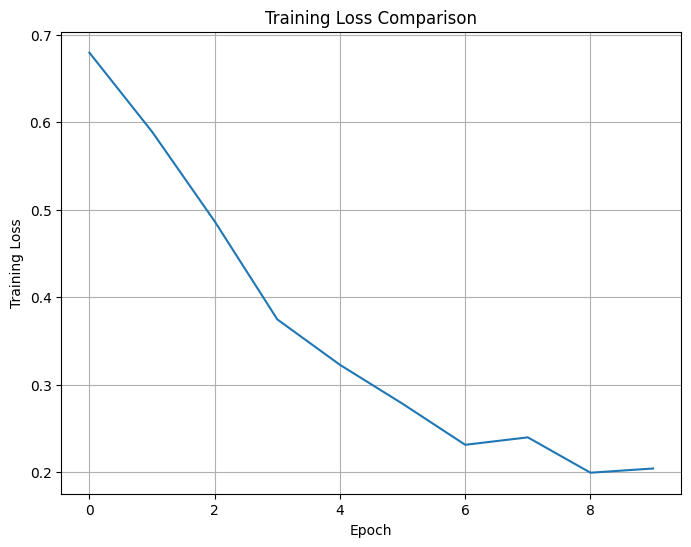

In [22]:
plt.figure(figsize=(8,6))

plt.plot(loss_3d, label="3D CNN")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")


plt.grid(True)

plt.show()

In [23]:
from sklearn.metrics import precision_score, recall_score, f1_score
from tqdm import tqdm

def evaluate_model(model, test_loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for X, y in tqdm(test_loader, desc="Evaluating"):

            X = X.to(device)

            outputs = model(X)

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(y.numpy())
            y_pred.extend(preds.cpu().numpy())

    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)

    return y_true, y_pred

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_three_confusion_matrices(y_true_3d, y_pred_3d):

    cm1 = confusion_matrix(y_true_3d, y_pred_3d)


    fig, axes = plt.subplots(1, 3, figsize=(18,5))

    titles = ["3D CNN"]

    cms = [cm1]

    for ax, cm, title in zip(axes, cms, titles):

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="magma",
            ax=ax,
            xticklabels=["Non-Shoplifter", "Shoplifter"],
            yticklabels=["Non-Shoplifter", "Shoplifter"]
        )

        ax.set_title(title)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

In [ ]:
y_true_3d, y_pred_3d = evaluate_model(model_3dcnn, test_loader)

Evaluating:  20%|██        | 6/30 [00:07<00:26,  1.09s/it]

TypeError: 'Axes' object is not iterable

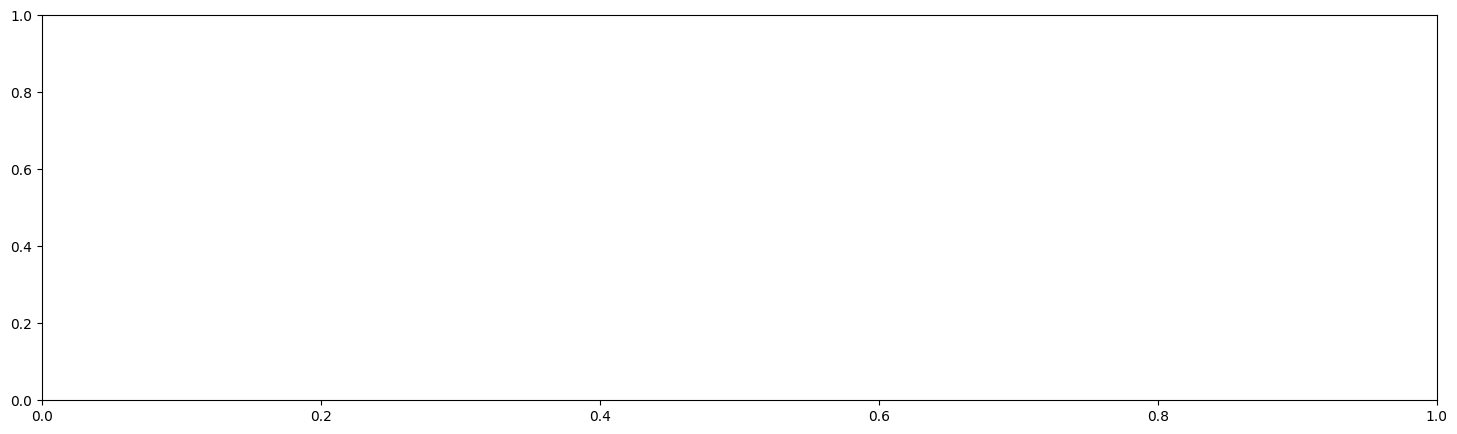

In [ ]:
plot_three_confusion_matrices(y_true_3d, y_pred_3d)